# 活性化関数の歴史と微分

ニューラルネットワークで使われる代表的な活性化関数を、**古い順**に並べ、それぞれの関数とその微分を重ね描きで可視化します。

| 順序 | 関数 | 普及時期 |
|---|---|---|
| ① | シグモイド関数 | 1986 年頃(誤差逆伝播法と共に普及) |
| ② | tanh 関数 | 1990 年代 |
| ③ | ソフトマックス関数 | Bridle (1990) |
| ④ | ReLU 関数 | Glorot et al. (2011) |
| ⑤ | Leaky ReLU 関数 | Maas et al. (2013) |

date:20260621 by Claude Opue4.6 and Megumi Kawakami

（シラバス12 活性化関数キーワード　Leaky ReLU 関数, ReLU 関数, tanh 関数, シグモイド関数, ソフトマックス関数, 勾配消失問題）

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント対応

plt.rcParams['figure.dpi'] = 100


## ① シグモイド関数 (Sigmoid)

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

微分:
$$\sigma'(x) = \sigma(x)\bigl(1 - \sigma(x)\bigr)$$

微分の最大値は $x=0$ で $\sigma'(0) = 0.25$。両端で 0 に張り付くため、**勾配消失問題**の主因となる。


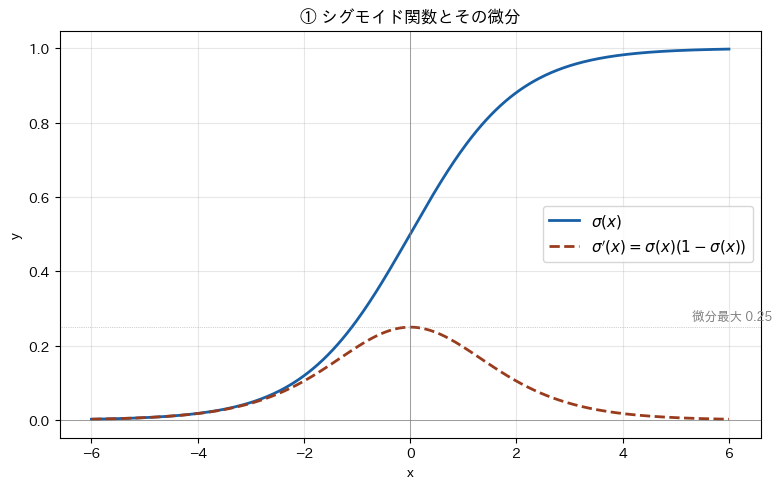

In [2]:
x = np.linspace(-6, 6, 400)
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_deriv = sigmoid * (1 - sigmoid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, sigmoid, label=r'$\sigma(x)$', color='#185FA5', linewidth=2)
ax.plot(x, sigmoid_deriv,
        label=r"$\sigma'(x) = \sigma(x)(1-\sigma(x))$",
        color='#993C1D', linewidth=2, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axhline(0.25, color='gray', linewidth=0.5, linestyle=':', alpha=0.7)
ax.text(5.3, 0.27, '微分最大 0.25', fontsize=9, color='gray')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('① シグモイド関数とその微分')
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ② tanh 関数 (Hyperbolic tangent : 双曲線正接)

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

微分:
$$\tanh'(x) = 1 - \tanh^2(x)$$

微分の最大値は $x=0$ で $\tanh'(0) = 1.0$。シグモイドより収束が速いが、両端で飽和する性質は同じ。


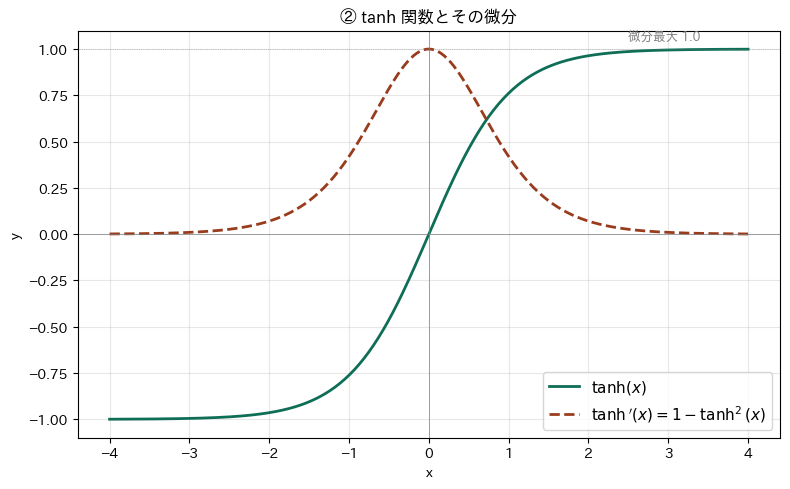

In [3]:
x = np.linspace(-4, 4, 400)
tanh_f = np.tanh(x)
tanh_deriv = 1 - tanh_f ** 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, tanh_f, label=r'$\tanh(x)$', color='#0F6E56', linewidth=2)
ax.plot(x, tanh_deriv,
        label=r"$\tanh'(x) = 1 - \tanh^2(x)$",
        color='#993C1D', linewidth=2, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axhline(1.0, color='gray', linewidth=0.5, linestyle=':', alpha=0.7)
ax.text(2.5, 1.05, '微分最大 1.0', fontsize=9, color='gray')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('② tanh 関数とその微分')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ③ ソフトマックス関数 (Softmax)

$$\mathrm{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

微分(ヤコビ行列):

$$\frac{\partial p_i}{\partial z_j} = \begin{cases} p_i(1 - p_i) & (i = j) \\ -p_i p_j & (i \neq j) \end{cases}$$

多入力多出力のため 1 次元グラフでは直接描けないので、ここでは **2 クラスの場合**($z_2 = 0$ 固定で $z_1$ を変化させたときの $p_1$)を表示する。この設定ではソフトマックスはシグモイドと等価になる。

***ソフトマックスは隠れ層に使う関数ではなく、出力を確率分布として解釈したいときの最終層専用ツール***


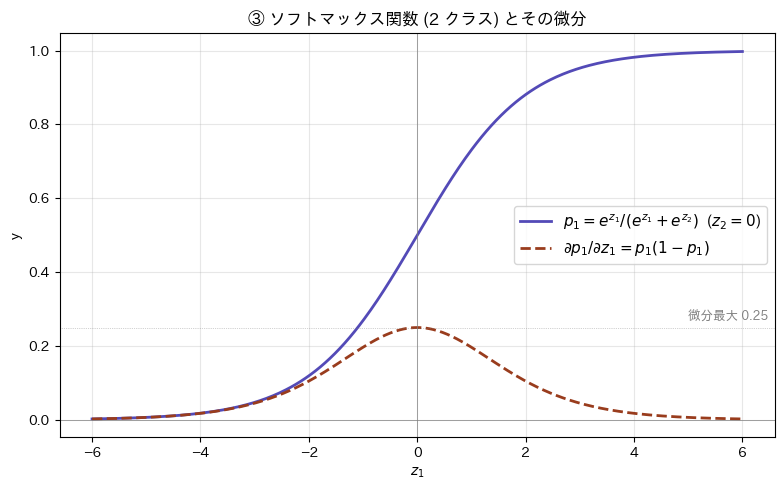

In [4]:
# 2 クラスのソフトマックス(z2 = 0 固定で z1 を変化)
z1 = np.linspace(-6, 6, 400)
z2 = 0.0
p1 = np.exp(z1) / (np.exp(z1) + np.exp(z2))
p1_deriv = p1 * (1 - p1)  # ∂p1/∂z1

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z1, p1,
        label=r'$p_1 = e^{z_1}/(e^{z_1}+e^{z_2})$  ($z_2=0$)',
        color='#534AB7', linewidth=2)
ax.plot(z1, p1_deriv,
        label=r"$\partial p_1 / \partial z_1 = p_1(1-p_1)$",
        color='#993C1D', linewidth=2, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.axhline(0.25, color='gray', linewidth=0.5, linestyle=':', alpha=0.7)
ax.text(5.0, 0.27, '微分最大 0.25', fontsize=9, color='gray')
ax.set_xlabel(r'$z_1$'); ax.set_ylabel('y')
ax.set_title('③ ソフトマックス関数 (2 クラス) とその微分')
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ④ ReLU 関数 (Rectified Linear Unit)

$$f(x) = \max(0, x)$$

微分:
$$f'(x) = \begin{cases} 1 & (x > 0) \\ 0 & (x < 0) \end{cases}$$

$x = 0$ では微分不可だが、慣例的に 0(または 1)とする。$x > 0$ で微分が常に 1 のため、深いネットワークでも勾配が縮まない。


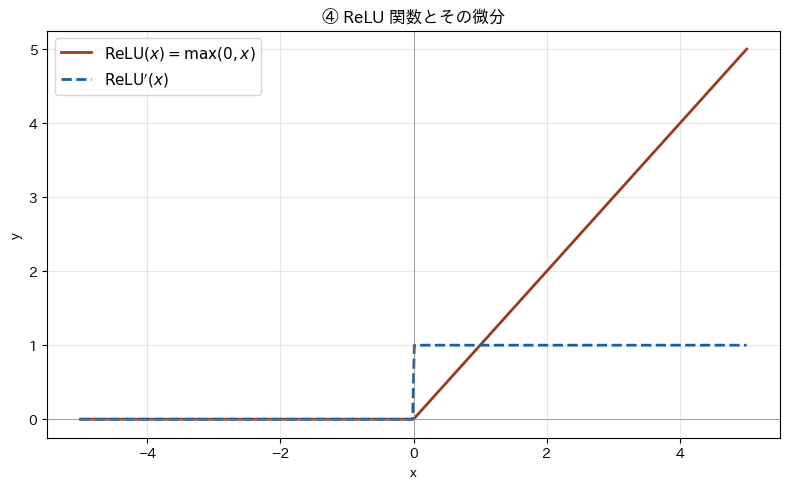

In [5]:
x = np.linspace(-5, 5, 400)
relu = np.maximum(0, x)
relu_deriv = np.where(x > 0, 1.0, 0.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, relu,
        label=r'$\mathrm{ReLU}(x) = \max(0, x)$',
        color='#993C1D', linewidth=2)
ax.plot(x, relu_deriv,
        label=r"$\mathrm{ReLU}'(x)$",
        color='#185FA5', linewidth=2, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('④ ReLU 関数とその微分')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## ⑤ Leaky ReLU 関数

$$f(x) = \max(\alpha x, x), \quad \alpha = 0.01 \,(\text{標準})$$

微分:
$$f'(x) = \begin{cases} 1 & (x > 0) \\ \alpha & (x < 0) \end{cases}$$

負側にも傾き $\alpha$ を残すことで Dying ReLU 問題を緩和。下のグラフでは可視化のため $\alpha = 0.1$ を使用。


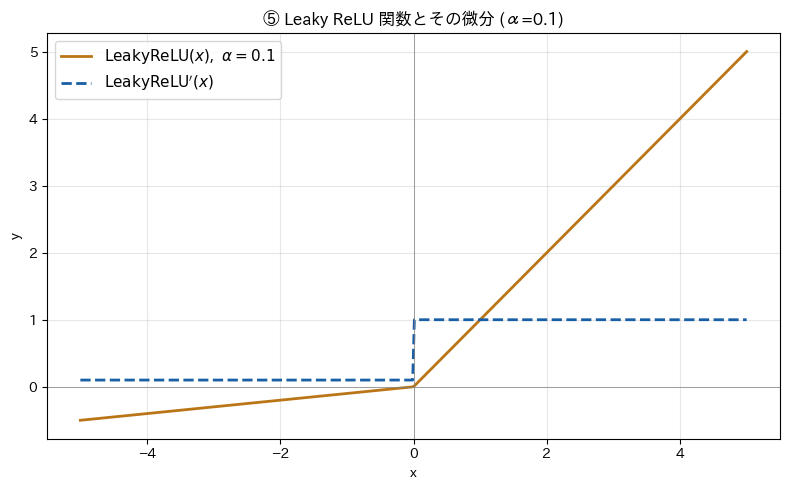

In [6]:
x = np.linspace(-5, 5, 400)
alpha = 0.1  # 可視化のため大きめ(標準は 0.01)
leaky = np.where(x > 0, x, alpha * x)
leaky_deriv = np.where(x > 0, 1.0, alpha)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, leaky,
        label=fr'$\mathrm{{LeakyReLU}}(x)$,  $\alpha={alpha}$',
        color='#BA7517', linewidth=2)
ax.plot(x, leaky_deriv,
        label=r"$\mathrm{LeakyReLU}'(x)$",
        color='#185FA5', linewidth=2, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'⑤ Leaky ReLU 関数とその微分 (α={alpha})')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## まとめ — 勾配消失問題から見た歴史の流れ

| 時期 | 隠れ層の主流 | 微分の最大値 | 勾配消失 |
|---|---|---|---|
| 〜 1980 年代 | シグモイド | 0.25 | 起きやすい |
| 1990 〜 2000 年代 | tanh | 1.0 | 緩和されるが残る |
| 2010 年代 〜 | ReLU / 派生 | 1 ($x > 0$) | ほぼ解消 |

**飽和する関数 → 飽和しない関数** への移行が、深層学習を可能にした最大の構造変化です。
